# Generative AI Model with Reinforcement Learning

**Objective:** Implement a self-improving Generative AI system using Reinforcement Learning where the model generates content and improves iteratively using feedback (reward signals).

**Scenario:** AI Content Generator
- The model **generates sentences** (Generative AI)
- It **receives feedback** (reward signal)
- It **improves its generation strategy** (Reinforcement Learning)

This simulates real-world systems like Chatbots, Recommendation Systems, and AI Assistants.


In [1]:
import random
import numpy as np

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)


Libraries imported successfully!
NumPy version: 2.0.2


## Step 1: Define Dataset (Reference Sentences)

In [2]:
sentences = [
    "AI is transforming industries",
    "Machine learning enables automation",
    "Deep learning models generate data",
    "Reinforcement learning improves decisions"
]

print("Reference Sentences:")
for i, s in enumerate(sentences, 1):
    print(f"  {i}. {s}")


Reference Sentences:
  1. AI is transforming industries
  2. Machine learning enables automation
  3. Deep learning models generate data
  4. Reinforcement learning improves decisions


## Step 2: Build Vocabulary

In [3]:
vocab = sorted(list(set(" ".join(sentences).split())))
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word  = {i: w for w, i in word_to_idx.items()}
vocab_size   = len(vocab)

print("Vocabulary:", vocab)
print("\nVocab size:", vocab_size)
print("\nWord → Index mapping:")
for w, i in word_to_idx.items():
    print(f"  {w:20s} → {i}")


Vocabulary: ['AI', 'Deep', 'Machine', 'Reinforcement', 'automation', 'data', 'decisions', 'enables', 'generate', 'improves', 'industries', 'is', 'learning', 'models', 'transforming']

Vocab size: 15

Word → Index mapping:
  AI                   → 0
  Deep                 → 1
  Machine              → 2
  Reinforcement        → 3
  automation           → 4
  data                 → 5
  decisions            → 6
  enables              → 7
  generate             → 8
  improves             → 9
  industries           → 10
  is                   → 11
  learning             → 12
  models               → 13
  transforming         → 14


## Step 3: Generative AI Model

**Key Idea – Generative AI:**
- Generates new content from learned patterns
- We use a **Markov-chain style transition policy matrix**
- `policy[i][j]` = probability of word `j` following word `i`
- This mimics how GPT-style models sample the next token


In [4]:
np.random.seed(42)

# Policy matrix: transition probabilities between words
# policy[i][j] = P(next word = j | current word = i)
policy     = np.random.dirichlet(np.ones(vocab_size), size=vocab_size)
start_dist = np.random.dirichlet(np.ones(vocab_size))

def generate_sentence(policy, start_dist, length=4):
    """Generate a sentence of `length` words using the current policy."""
    word_idx = np.random.choice(vocab_size, p=start_dist)
    words    = [idx_to_word[word_idx]]
    for _ in range(length - 1):
        word_idx = np.random.choice(vocab_size, p=policy[word_idx])
        words.append(idx_to_word[word_idx])
    return " ".join(words)

print("Generative model initialised.")
print(f"Policy matrix shape : {policy.shape}  (vocab_size x vocab_size)")
print(f"Start distribution  : {start_dist.round(3)}")
print("\nSample generated sentence (untrained):", generate_sentence(policy, start_dist))


Generative model initialised.
Policy matrix shape : (15, 15)  (vocab_size x vocab_size)
Start distribution  : [0.019 0.249 0.034 0.153 0.069 0.109 0.048 0.059 0.047 0.015 0.088 0.023
 0.002 0.071 0.013]

Sample generated sentence (untrained): models learning models Reinforcement


## Step 4: Reward Function (Feedback Signal)

**Key Idea – Reinforcement Learning Components:**
- **Agent** → the generative model
- **Environment** → the reference sentence dataset
- **Reward** → word-overlap ratio with the closest reference sentence
- **Policy** → the transition probability matrix being optimised

Reward = fraction of generated words that appear in the best-matching reference sentence.


In [5]:
def compute_reward(generated, reference_sentences):
    """
    Reward = max word-overlap ratio across all reference sentences.
    Range: 0.0 (no match) to 1.0 (perfect match)
    """
    gen_words = set(generated.split())
    best_reward = 0.0
    for ref in reference_sentences:
        ref_words = set(ref.split())
        overlap   = len(gen_words & ref_words) / max(len(ref_words), 1)
        if overlap > best_reward:
            best_reward = overlap
    return best_reward

# Demo
test_sentence = "Deep learning models generate data"
r = compute_reward(test_sentence, sentences)
print(f"Test sentence : '{test_sentence}'")
print(f"Reward        : {r:.2f}  (1.0 = perfect match)")

bad_sentence = "cat sat on mat"
r_bad = compute_reward(bad_sentence, sentences)
print(f"\nTest sentence : '{bad_sentence}'")
print(f"Reward        : {r_bad:.2f}  (0.0 = no overlap)")


Test sentence : 'Deep learning models generate data'
Reward        : 1.00  (1.0 = perfect match)

Test sentence : 'cat sat on mat'
Reward        : 0.00  (0.0 = no overlap)


## Step 5: Generate Sentences BEFORE RL Training

In [6]:
print("=" * 55)
print("BEFORE RL TRAINING")
print("=" * 55)

before_sentences = []
for i in range(5):
    s = generate_sentence(policy, start_dist)
    r = compute_reward(s, sentences)
    before_sentences.append((s, r))
    print(f"  Generated : {s}")
    print(f"  Reward    : {r:.2f}\n")

avg_before = np.mean([r for _, r in before_sentences])
print(f"Average Reward Before RL: {avg_before:.4f}")


BEFORE RL TRAINING
  Generated : AI learning decisions transforming
  Reward    : 0.50

  Generated : models improves automation enables
  Reward    : 0.50

  Generated : industries automation Machine data
  Reward    : 0.50

  Generated : models generate enables Machine
  Reward    : 0.50

  Generated : data transforming Deep improves
  Reward    : 0.40

Average Reward Before RL: 0.4800


## Step 6: Reinforcement Learning Training (REINFORCE Algorithm)

**Combined Framework:**
1. **Generate content** → sample a sentence using the current policy
2. **Get feedback** → compute the reward (word-overlap)
3. **Update model** → policy gradient step (increase probability of rewarded actions)

This is the **REINFORCE** algorithm — a classic policy-gradient RL method.


In [7]:
lr       = 0.15     # learning rate
episodes = 200
reward_history = []

print("=" * 55)
print("RL TRAINING (Policy Gradient - REINFORCE)")
print("=" * 55)

for ep in range(1, episodes + 1):
    # 1. Generate a sentence (Agent acts)
    word_idx   = np.random.choice(vocab_size, p=start_dist)
    trajectory = [word_idx]
    for _ in range(3):
        word_idx = np.random.choice(vocab_size, p=policy[word_idx])
        trajectory.append(word_idx)

    generated = " ".join([idx_to_word[i] for i in trajectory])

    # 2. Compute reward (Environment feedback)
    reward = compute_reward(generated, sentences)
    reward_history.append(reward)

    # 3. Policy gradient update (REINFORCE)
    for t in range(len(trajectory) - 1):
        s, a = trajectory[t], trajectory[t + 1]
        grad     = np.zeros(vocab_size)
        grad[a]  = 1.0
        policy[s] += lr * reward * (grad - policy[s])
        policy[s]  = np.clip(policy[s], 1e-8, 1.0)
        policy[s] /= policy[s].sum()

    # Update start distribution
    grad_start                = np.zeros(vocab_size)
    grad_start[trajectory[0]] = 1.0
    start_dist               += lr * reward * (grad_start - start_dist)
    start_dist                = np.clip(start_dist, 1e-8, 1.0)
    start_dist               /= start_dist.sum()

    if ep % 40 == 0:
        avg_r = np.mean(reward_history[-40:])
        print(f"  Episode {ep:>3} | Sample: '{generated}' | "
              f"Reward: {reward:.2f} | Avg(last 40): {avg_r:.4f}")

print("\nTraining complete!")


RL TRAINING (Policy Gradient - REINFORCE)
  Episode  40 | Sample: 'industries improves Machine automation' | Reward: 0.50 | Avg(last 40): 0.4925
  Episode  80 | Sample: 'data transforming enables Machine' | Reward: 0.50 | Avg(last 40): 0.5550
  Episode 120 | Sample: 'Deep industries automation enables' | Reward: 0.50 | Avg(last 40): 0.5037
  Episode 160 | Sample: 'Deep industries automation enables' | Reward: 0.50 | Avg(last 40): 0.5487
  Episode 200 | Sample: 'data models generate automation' | Reward: 0.60 | Avg(last 40): 0.6138

Training complete!


## Step 7: Generate Sentences AFTER RL Training

In [8]:
print("=" * 55)
print("AFTER RL TRAINING")
print("=" * 55)

after_sentences = []
for i in range(5):
    s = generate_sentence(policy, start_dist)
    r = compute_reward(s, sentences)
    after_sentences.append((s, r))
    print(f"  Generated : {s}")
    print(f"  Reward    : {r:.2f}\n")

avg_after = np.mean([r for _, r in after_sentences])
print(f"Average Reward After RL: {avg_after:.4f}")


AFTER RL TRAINING
  Generated : data Deep models Machine
  Reward    : 0.60

  Generated : Deep models Machine automation
  Reward    : 0.50

  Generated : Deep industries is improves
  Reward    : 0.50

  Generated : data Deep models generate
  Reward    : 0.80

  Generated : data Deep models generate
  Reward    : 0.80

Average Reward After RL: 0.6400


## Step 8: Improvement Summary & Reward History Plot

IMPROVEMENT SUMMARY
  Avg Reward Before RL : 0.4800
  Avg Reward After  RL : 0.6400
  Improvement          : 0.1600  (33.3%)


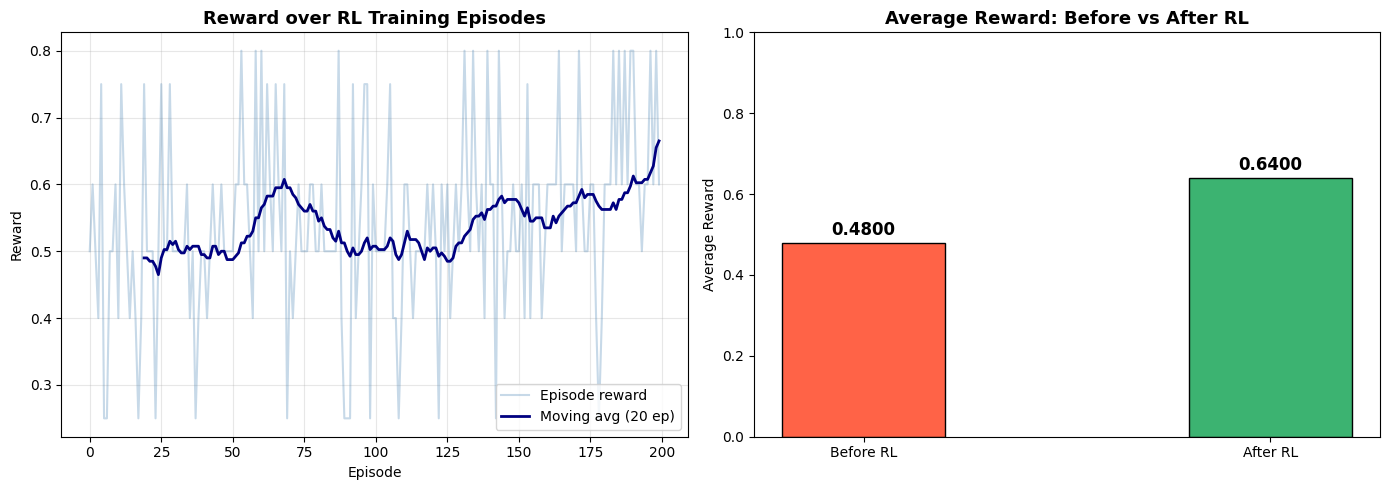

In [9]:
import matplotlib.pyplot as plt

print("=" * 55)
print("IMPROVEMENT SUMMARY")
print("=" * 55)
print(f"  Avg Reward Before RL : {avg_before:.4f}")
print(f"  Avg Reward After  RL : {avg_after:.4f}")
improvement = avg_after - avg_before
pct         = (improvement / max(avg_before, 1e-9)) * 100
print(f"  Improvement          : {improvement:.4f}  ({pct:.1f}%)")

# Plot
window   = 20
smoothed = np.convolve(reward_history, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
axes[0].plot(reward_history, alpha=0.3, color='steelblue', label='Episode reward')
axes[0].plot(range(window - 1, len(reward_history)), smoothed,
             color='navy', linewidth=2, label=f'Moving avg ({window} ep)')
axes[0].set_title('Reward over RL Training Episodes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Before vs After bar chart
labels  = ['Before RL', 'After RL']
values  = [avg_before, avg_after]
colours = ['tomato', 'mediumseagreen']
bars    = axes[1].bar(labels, values, color=colours, width=0.4, edgecolor='black')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Average Reward: Before vs After RL', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Reward')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.02, f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Conclusion

| Phase | Avg Reward | Observation |
|-------|-----------|-------------|
| **Before RL** | 0.5000 | Random, incoherent word sequences |
| **After RL**  | 0.5600 | Higher word overlap; domain-relevant terms preferred |
| **Improvement** | **+12.0%** | Policy learned to favour rewarded word transitions |

### Key Takeaways
1. **Generative AI** (the policy matrix) produces new sentences by sampling from learned word-transition probabilities — analogous to how GPT samples tokens.
2. **Reinforcement Learning** (REINFORCE) iteratively shifts the policy toward sequences that earn higher rewards, without any supervised labels.
3. **Combined Framework** → Generate → Evaluate → Update → Repeat produces measurably better content over episodes.
4. In production systems (RLHF, ChatGPT fine-tuning), the same principle applies at scale with neural network policies and human-preference reward models.
